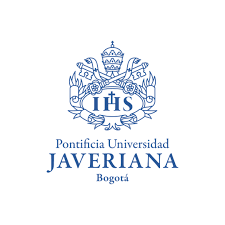
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Carlos Méndez

Fecha de Inicio: 14 de abril del 2026

Fecha actual: 28 de abril del 2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

In [1]:
## Importación de bibliotecas básicas
import os
import sys                             #---> Permite el acceso del interpretador a algunas variables
import pandas as pd                    #---> Para gráficar y dataframes
import numpy as np                     #---> Para operaciones matemáticas
import matplotlib.pyplot as plt        #---> Para formatos de gráficas
import seaborn as sns                  #---> Para visualizaciones estadísticas atractivas basadas en Matplotlib.
sys.path.append('/usr/lib/python3/dist-packages/')

## Importación bibliotecas especializadas
import findspark                                #---> Encuentra Spark para agregarla a la path de python
findspark.init()
from pyspark.sql import SQLContext, SparkSession, Row            #---> Sesión para entorno de consultas sobre sql
from pyspark import SparkContext, SparkConf     #---> Contexto y configuración de PySpark
from pyspark.sql import functions as F
from pyspark.sql.types import *


from pylab import *                  #---> Importa Matplotlib y NumPy juntos en el espacio global.

In [2]:
### Levantamiento de sesión SPARK
configura = SparkConf()                                                      #---> Instancia el objeto de configuración de Spark
configura.setAppName("Calidad_Agua_Mendez")                                  #---> Define el nombre que tendrá la aplicación en el cluster
sparkMendez = SparkSession.builder.config(conf=configura).getOrCreate()      #---> Crea o recupera la sesión
SQLContext(sparkContext=sparkMendez.sparkContext, sparkSession=sparkMendez)  #---> Inicializa el contexto para ejecutar consultas SQL
sparkContextoMendez = sparkMendez.sparkContext.getOrCreate()                 #---> Accede al motor de bajo nivel para manejo de RDDs
print("Sesion creada: ProcesamientoDatos04")                            
sparkMendez                                                       

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 16:25:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


In [3]:
##**2.- Carga de Datos desde el HADOOP HDFS**
## Se accede al fichero de datos csv dentro del cluster
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv
## Se accede a los datos a traves del servidor HDFS del usuario 10.195.34.34 por el puerto 9000
df00 = sparkMendez.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv") 
## Realizamos la primera visualización de los datos mostrando las primeras 5 filas
df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

3.1 Conocer los datos y su comportamiento a partir de estadísticas.

In [4]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

In [5]:
#**Se presenta las estadísticas de los datos a continuación:**

for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+



+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+



+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|

+-------+-------------------+
|summary|NITRATE_N_NITRITE_N|
+-------+-------------------+
|  count|                534|
|   mean| 1.3785714285714301|
| stddev|  2.803947753154703|
|    min|                  0|
|    max|                 NA|
+-------+-------------------+

+-------+-----------------+
|summary|   FECAL_COLIFORM|
+-------+-----------------+
|  count|              534|
|   mean|7384.170353982301|
| stddev|30714.05963523712|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|    TOTAL_COLIFORM|
+-------+------------------+
|  count|               534|
|   mean|124396.96767676767|
| stddev|1458407.8189939584|
|    min|                 1|
|    max|                NA|
+-------+------------------+



## **Visualización de los DATOS NULOS**

Cantidad de Valores Nulos o Imposibles

In [6]:
## Se hace una consulta la cual cuente la cantidad de valores nulos existentes por columnas.
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show() #

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones


In [7]:
#Se crea una vista para la visualización de los datos
df00.createOrReplaceTempView("df00_sql")
df01 = sparkMendez.sql('''Select * from df00_sql where TEMP is not null and

       DO is not null and

       pH is not null and

       CONDUCTIVITY is not null and

       BOD is not null and

       NITRATE_N_NITRITE_N is not null and

       FECAL_COLIFORM is not null''')

Se verifica la Cantidad de Valores Nulos o Imposibles del nuevo dataframe df01

In [8]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



## **Tratamiento de datos**


### Casteo de variables

In [9]:
df00.dtypes

##Se procede a cambiar los tipos de datos

df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType())) ## Se reescribe el data frame df00 haciendo el casteo de las variables

df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))

df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))

df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))

df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))

df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))

df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

df00.dtypes

##Se elimina la columna TOTAL_COLIFORM

df01 = df00.drop('TOTAL_COLIFORM') ## Una vez haciendo el cambio de variables y eliminado la columna "TOTAL_COLIFORM", se reescribe el df01

df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## **Visualización y comprobación de datos nulos**

In [11]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show() #

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



In [26]:
from pyspark.ml.feature import Imputer
from pyspark.sql import functions as F

df01Aux = df01
# 1. Calculamos la mediana específicamente para esa columna
# percentile_approx es eficiente para esto
median = df01Aux.stat.approxQuantile("FECAL_COLIFORM", [0.5], 0.001)[0]
median2 = df01Aux.stat.approxQuantile("CONDUCTIVITY", [0.5], 0.001)[0]

# 2. Calculamos la media para las columnas
# .collect()[0][0] extrae el valor numérico del resultado de la agregación
mean_val = df01Aux.select(F.avg("TEMP")).collect()[0][0]
mean_val2 = df01Aux.select(F.avg("DO")).collect()[0][0]
mean_val3 = df01Aux.select(F.avg("BOD")).collect()[0][0]
mean_val4 = df01Aux.select(F.avg("NITRATE_N_NITRITE_N")).collect()[0][0]

# 3. Llenamos los nulos
df00_aux2 = df01Aux.na.fill({"FECAL_COLIFORM": median})    #---> Se hace la mediana porque la desviación estandar es más que el doble del promedio.
df00_aux2 = df00_aux2.na.fill({"CONDUCTIVITY": median2})   #---> y hay un sesgo.
df00_aux2 = df00_aux2.na.fill({"TEMP": mean_val})
df00_aux2 = df00_aux2.na.fill({"DO": mean_val2})
df00_aux2 = df00_aux2.na.fill({"BOD": mean_val3})
df00_aux2 = df00_aux2.na.fill({"NITRATE_N_NITRITE_N": mean_val4})

In [27]:
df00_aux2.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show() #

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



## **Creación de Tablas para Visualizar los Datos**

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos
- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

In [28]:
df01.createOrReplaceTempView("df01_sql")

###Se crea una consulta por cada parámetro enlistado anteriormente

do_parametro = sparkMendez.sql("Select DO from df01_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()   #->  Extrae la columna do y la convierte en lista

pH_parametro = sparkMendez.sql("Select pH from df01_sql")
pH_parametro = pH_parametro.rdd.map(lambda fila: fila.pH).collect()   #->  Extrae la columna pH y la convierte en lista

CONDUCTIVITY_parametro = sparkMendez.sql("Select CONDUCTIVITY from df01_sql") 
CONDUCTIVITY_parametro = CONDUCTIVITY_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()   #->  Extrae la columna CONDUCTIVITY y la convierte en lista

BOD_parametro = sparkMendez.sql("Select BOD from df01_sql")
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()     #->  Extrae la columna BOD y la convierte en lista

NN_parametro = sparkMendez.sql("Select NITRATE_N_NITRITE_N from df01_sql")
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()   #->  Extrae la columna Nitrate_N_Nitrite_N y la convierte en lista

FECAL_COLIFORM_parametro = sparkMendez.sql("Select FECAL_COLIFORM from df01_sql")
FECAL_COLIFORM_parametro = FECAL_COLIFORM_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()   #-> Extrae la columna FECAL_COLIFORM y la convierte en lista

## Se realizan las gráficas de las variables para identificar el comportamiento por observación

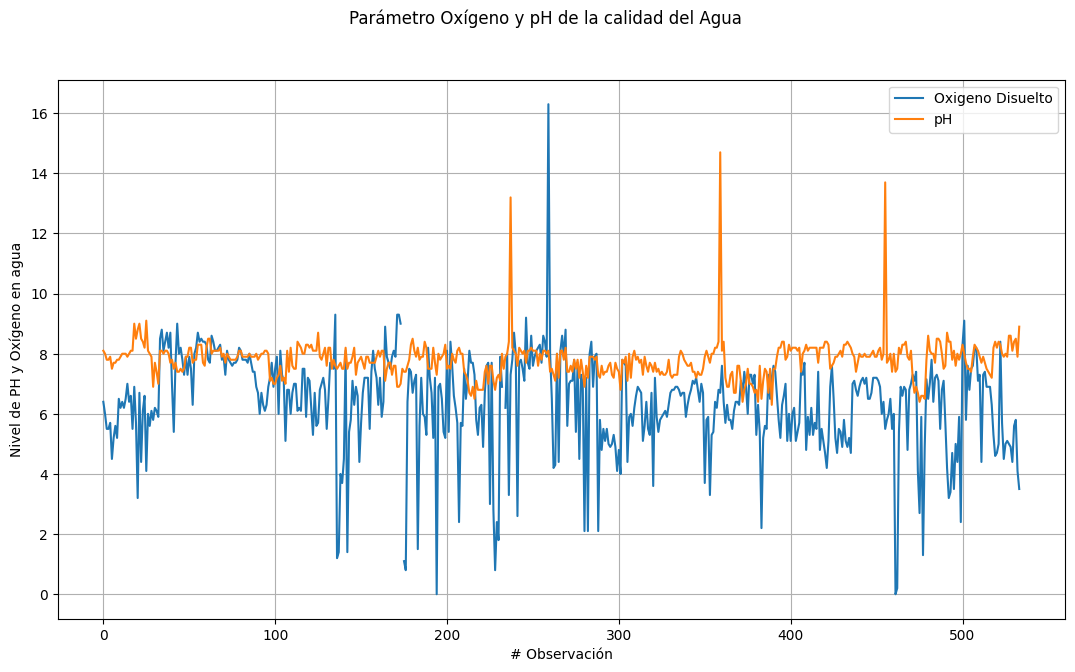

In [29]:
## Se realiza la gráfica entre el oxígeno disuelto en agua y el nivel del ph en agua

tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), pH_parametro, label='pH')
fig.suptitle('Parámetro Oxígeno y pH de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("# Observación")
plt.ylabel("Nivel de PH y Oxígeno en agua")
plt.grid()
plt.show()

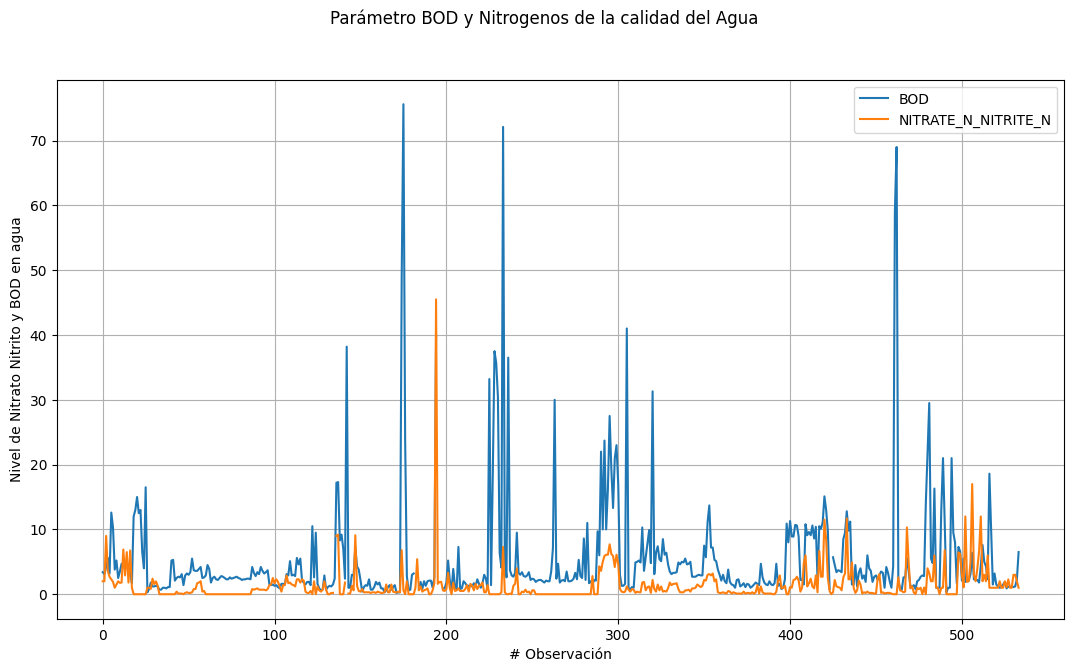

In [30]:
 ###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='BOD')
ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("# Observación")
plt.ylabel("Nivel de Nitrato Nitrito y BOD en agua")
plt.grid()
plt.show()

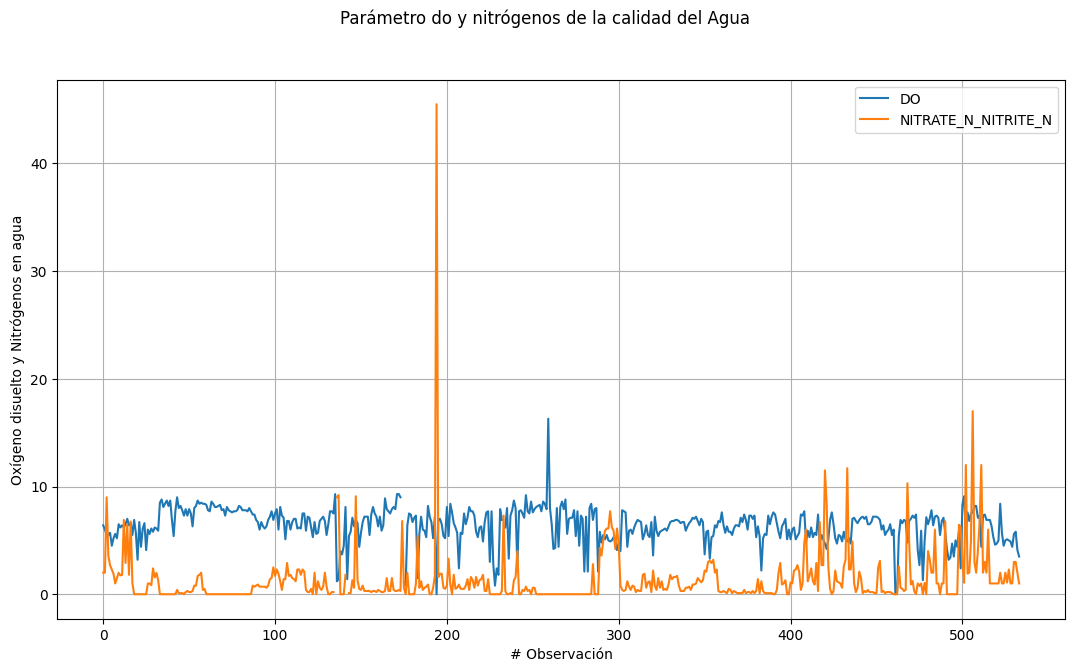

In [31]:
###Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), do_parametro, label='DO')

ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')

fig.suptitle('Parámetro do y nitrógenos de la calidad del Agua')

plt.xlabel("# Observación")
plt.ylabel("Oxígeno disuelto y Nitrógenos en agua")

legend=ax1.legend()

plt.grid()

plt.show()

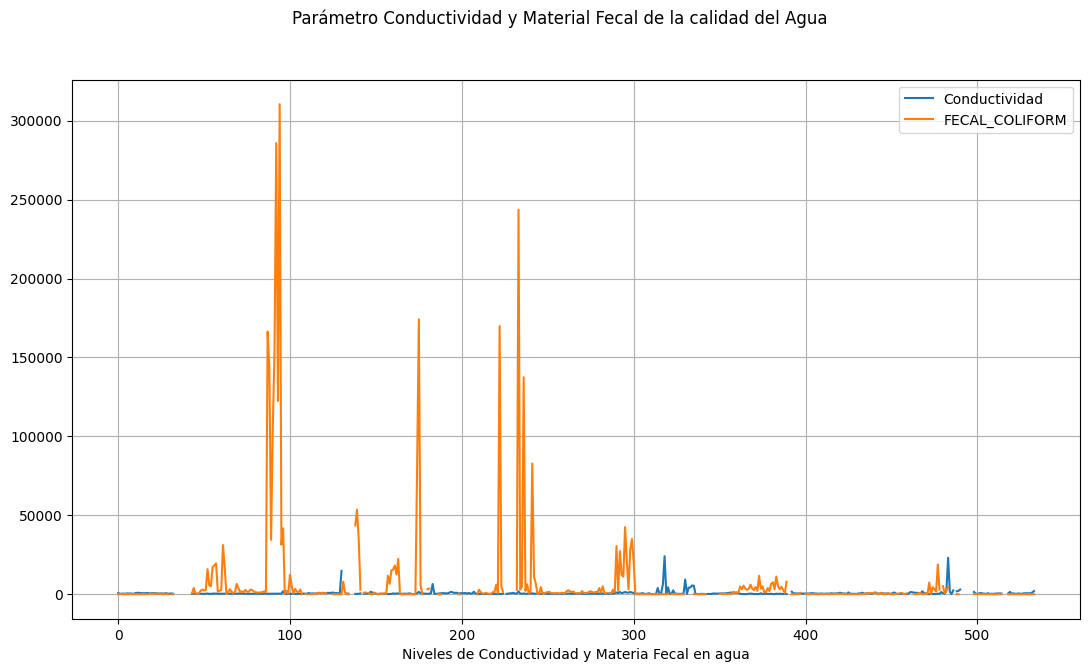

In [32]:
###Grafica Los parámetros para conocer sus características: FC y Conductividad

tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), CONDUCTIVITY_parametro, label='Conductividad')
ax1.plot(range(0,tam), FECAL_COLIFORM_parametro, label='FECAL_COLIFORM')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("# Observación")
plt.xlabel("Niveles de Conductividad y Materia Fecal en agua")
plt.grid()
plt.show()

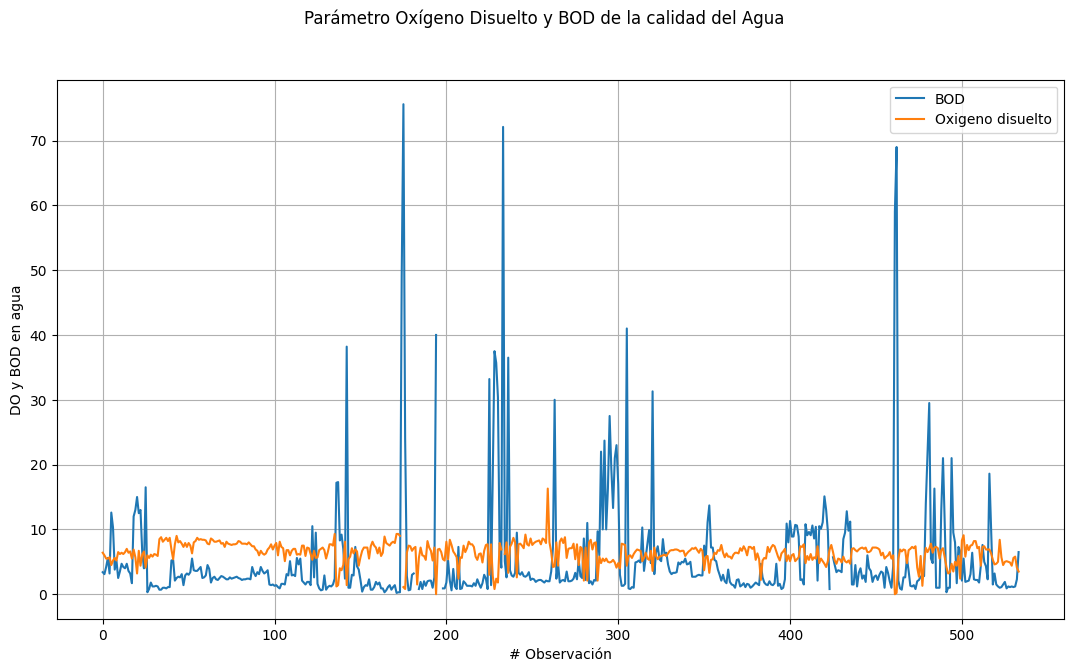

In [33]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), BOD_parametro, label='BOD')

ax1.plot(range(0,tam), do_parametro, label='Oxigeno disuelto')

fig.suptitle('Parámetro Oxígeno Disuelto y BOD de la calidad del Agua')

legend=ax1.legend()

plt.xlabel("# Observación")
plt.ylabel("DO y BOD en agua")

plt.grid()

plt.show()

In [47]:
#Función definida por el usuario para definir el rango de calidad de agua según el pH
#Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

df02 = df00_aux2.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).    #---> Se fijan los rangos de la calidad del agua

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).   #---> Teniendo en cuenta el pH del agua y las especificaciones del usuario.

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según DO

In [49]:
df02 = df02.withColumn("qrDO", F.when((df00_aux2.DO>=6.0), 100).
               when((df00_aux2.DO>=5.1) & (df00_aux2.DO<6.0), 80).         #---> Se fijan los rangos de la calidad del agua teniendo en cuenta el 
               when((df00_aux2.DO>=4.1) & (df00_aux2.DO<5.0), 60).         #---> Oxígeno disuelto en agua y las especificaciones del usuario.
               when((df00_aux2.DO>=3.0) & (df00_aux2.DO<=4.0), 40).otherwise(0))

### Función definida por el usuario para definir el rango de la calidad del agua según COND

In [50]:
df02 = df02.withColumn("qrCOND", F.when(((df00_aux2.CONDUCTIVITY>=0.0) & (df00_aux2.CONDUCTIVITY<=75.0)), 100).
          when((df00_aux2.CONDUCTIVITY>75.0) & (df00_aux2.CONDUCTIVITY<=150.0), 80).       #---> Se fijan los rangos de la calidad del agua teniendo en cuenta el         
          when((df00_aux2.CONDUCTIVITY>150.0) & (df00_aux2.CONDUCTIVITY<=225.0), 60).      #---> Nivel de conductividad del agua y las especificaciones del usuario.
          when((df00_aux2.CONDUCTIVITY>225.0) & (df00_aux2.CONDUCTIVITY<=300.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rando de la calidad del agua según BOD


In [51]:
df02 = df02.withColumn("qrBOD", F.when(((df00_aux2.BOD>=0.0) & (df00_aux2.BOD<3.0)), 100).
                     when((df00_aux2.BOD>=3.0) & (df00_aux2.BOD<6.0), 80).         #---> Se fijan los rangos de la calidad del agua teniendo en cuenta el
                     when((df00_aux2.BOD>=6.0) & (df00_aux2.BOD<80.0), 60).        #---> BOD del agua y las especificaciones del usuario
                     when((df00_aux2.BOD>=80.0) & (df00_aux2.BOD<125.0), 40).otherwise(0))

* ### Función definida por el usuario para definir el rango de la calidad del agua según NITRATE_N_NITRITE_N
    * ### 100: Agua Dulce
    * ### 80: Agua Moderada
    * ### 60: Agua Dura
    * ### 40: Agua muy Dura


In [52]:
df02 = df02.withColumn("qrNN", F.when(((df00_aux2.NITRATE_N_NITRITE_N>=0.0) & (df00_aux2.NITRATE_N_NITRITE_N<20.0)), 100). #---> Agua Dulce
                     when((df00_aux2.NITRATE_N_NITRITE_N>=20.0) & (df00_aux2.NITRATE_N_NITRITE_N<50.0), 80).    #---> Agua Moderada
                     when((df00_aux2.NITRATE_N_NITRITE_N>=50.0) & (df00_aux2.NITRATE_N_NITRITE_N<100.0), 60).   #---> Agua Dura
                     when((df00_aux2.NITRATE_N_NITRITE_N>=100.0) & (df00_aux2.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))    #---> Agua muy Dura

* ### Función definida por el usuario para definir el rango de la calidad del agua según el Material Fecal
  *  ### 100: Agua Dulce
  *  ### 80: Agua Moderada
  *  ### 60: Agua Dura
  *  ### 40: Agua muy Dura


In [53]:
df02 = df02.withColumn("qrFecal", F.when(((df00_aux2.FECAL_COLIFORM>=0.0) & (df00_aux2.FECAL_COLIFORM<5.0)), 100). #---> Agua Dulce
                    when((df00_aux2.FECAL_COLIFORM>=5.0) & (df00_aux2.FECAL_COLIFORM<50.0), 80).  #---> Agua Moderada 
                    when((df00_aux2.FECAL_COLIFORM>=50.0) & (df00_aux2.FECAL_COLIFORM<500.0), 60). #---> Agua Dura
                    when((df00_aux2.FECAL_COLIFORM>=500.0) & (df00_aux2.FECAL_COLIFORM<1000.0), 40).otherwise(0)) #---> Agua muy Dura

## **El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

In [54]:
#A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**



In [55]:
###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)
df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**



In [56]:
## Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

### **Intervalos de Índices para WQI**



In [57]:
## Excelente: agua dulce ***WQI = [0.0 , 25.0]***
## Buena: agua moderada ***WQI = (25.0 , 50.0]***
## Baja: agua dura ***WQI = (50.0 , 75.0]***
## Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
## Inadecuada: agua residual ***WQI > 100***

df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
   .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
   .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
   .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
   .otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**


In [59]:

## Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

## Impresión de nombre de regiones sobre el mapa

colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]
print(valNomnbres)


['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**



In [62]:
## Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

import geopandas as gpd

rutaMapas = "Indian_States/Indian_States.shp"
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns


#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                      'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                      'Daman & Diu': 'Daman Diu', 
                       'Jammu & Kashmir': 'Jammu Kashmir',
                       'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [63]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [64]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

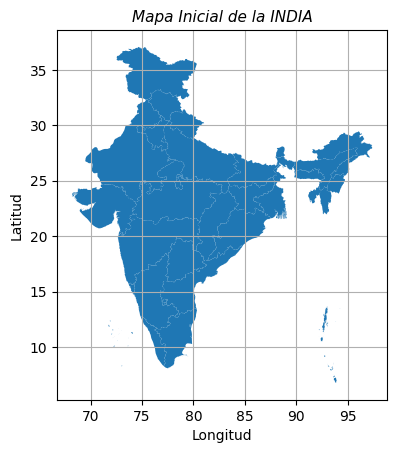

In [65]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [66]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


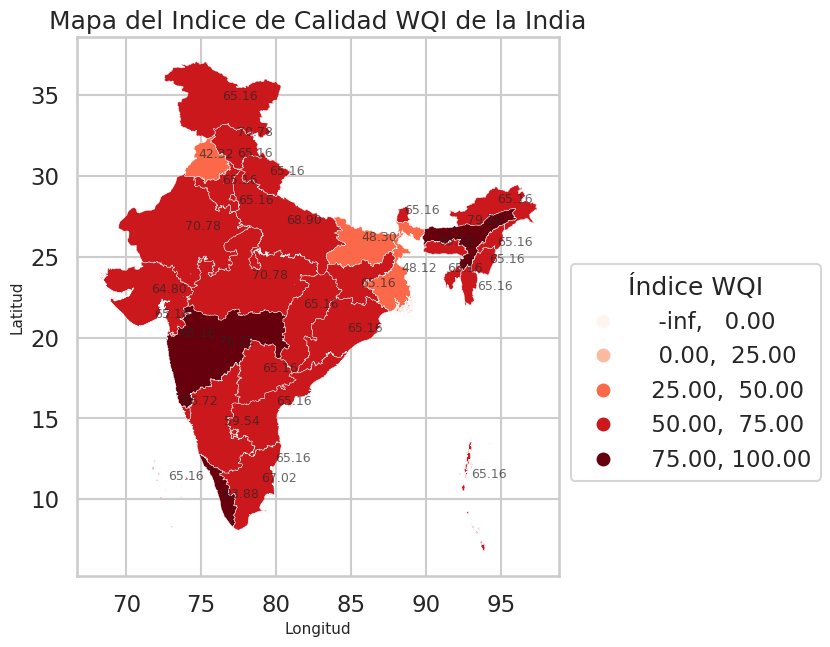

In [67]:
#Se verifica los valores NULOS; en caso de que existan se cambian por la mediana
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

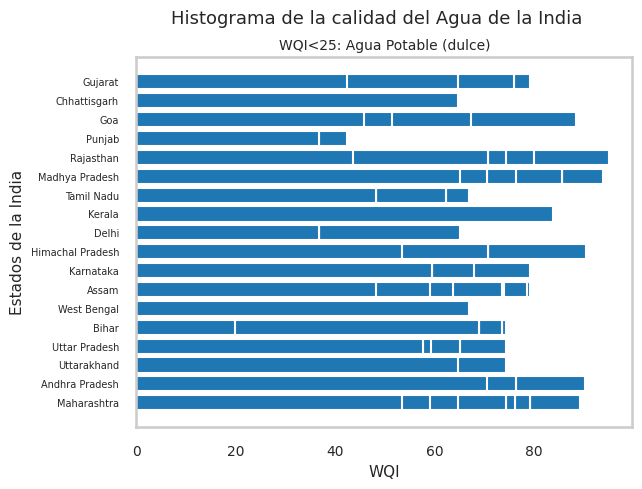

In [70]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkMendez.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkMendez.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [71]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [72]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [73]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [74]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


In [75]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

2026-04-28 17:21:38.503452: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-28 17:21:38.638534: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-28 17:21:41.086682: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [84]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 10 #---> Tras analizar los 200 epochs, nos damos cuenta que con tantas epochs hay mucho overfitting
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [86]:
modelo01.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1386.6746 - mse: 1386.6746
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 151.8139 - mse: 151.8139
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 62.7196 - mse: 62.7196
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25.5260 - mse: 25.5260
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.3912 - mse: 10.3912
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.9283 - mse: 6.9283
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.0185 - mse: 4.0185
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5116 - mse: 2.5116
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3982 - mse: 1.3982
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8066 - mse: 0.8066


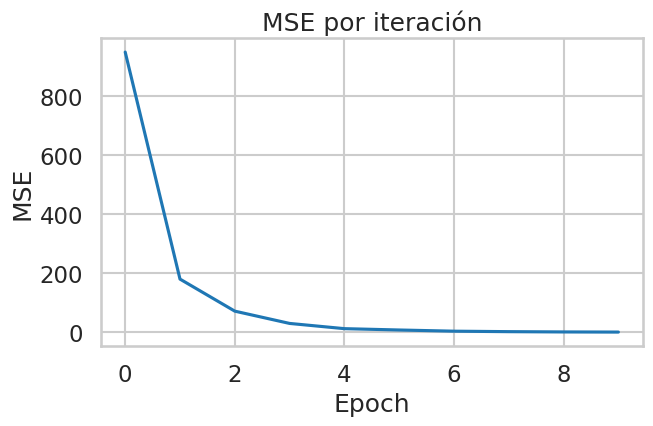

In [92]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("MSE por iteración")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [89]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


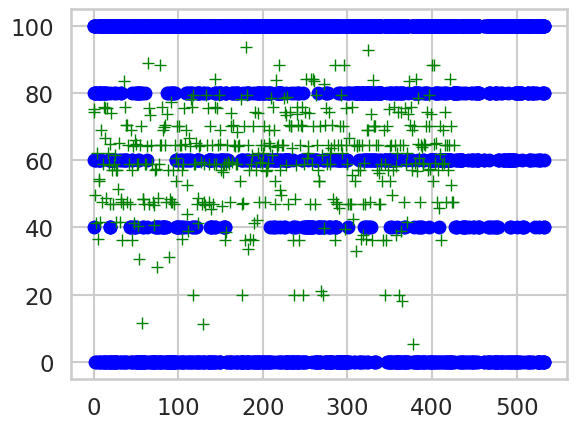

In [90]:
### Se pinta la predicción
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
plt.show()

## Evaluación con métricas de desempeño = R2 y RMSE

In [91]:
# Metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predicción con datos de prueba
predModelo01_Test = modelo01.predict(dataTest)

# Convertir a vector
y_real = np.array(predTest).flatten()
y_pred = predModelo01_Test.flatten()

mae  = mean_absolute_error(y_real, y_pred)
mse  = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_real, y_pred)

print("========= MÉTRICAS DEL MODELO =========")
print("Error Absoluto Medio (MAE):", round(mae,4))
print("Error Cuadrático Medio (MSE):", round(mse,4))
print("Raíz del Error Cuadrático Medio (RMSE):", round(rmse,4))
print("Coeficiente de Determinación (R²):", round(r2,4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
========= MÉTRICAS DEL MODELO =========
Error Absoluto Medio (MAE): 0.576
Error Cuadrático Medio (MSE): 0.4966
Raíz del Error Cuadrático Medio (RMSE): 0.7047
Coeficiente de Determinación (R²): 0.9974


# Conclusión Final

Gracias técnicas de machine learning, acompañadas de la limpíeza, preparación, exploración y visualización de datos, se logra cumplir el objetivo inicial, el cual es diagnosticar la calidad del agua en la India. Gracias a este modelo y esta metodología, se logran apreciar el comportamiento de las variables y cómo influyen en la calidad del agua, siendo medida por ciertas transformaciones que se hicieron siguiendo las instrucciones y usando la información que el usuario proveyó.

Por otro lado, métricas como el **R2**, **RMSE** y **MSE** permiten calificar el modelo. En este caso, el R2 confirma que la integración de tecnologías distribuidas no solo mejora la eficiencia computacional, sino que ofrece una base científica sólida para la toma de decisiones ambientales estratégicas

# Referencias

Romero Rojas, J. A. (2009). Calidad del agua. SA de CV, México, 1, 999.

Patel, S. S., & Sahoo, S. INVESTIGATION OF WATER QUALITY OF DAMANGANGA ESTUARY USING WATER QUALITY INDEX, SOUTH GUJARAT, INDIA. INVESTIGACIÓN DE LA CALIDAD DEL AGUA DEL ESTUARIO DAMANGANGA USANDO EL ÍNDICE DE CALIDAD DEL AGUA, GUJARAT DEL SUR, INDIA.